In [1]:
import json
import math
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt

# -------------------
# PATHS
# -------------------
TRAIN_JSON = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v2/instances_val_filtered2.json")
TRAIN_IMG_DIR = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v2/val_working2")  # contains 000000xxxxxx.jpg

# Optional (you said you'll use COCO val as test later; not used in training cells below)
# VAL_JSON = Path("")
# VAL_IMG_DIR = Path("")

# -------------------
# TRAINING SETTINGS
# -------------------
SEED = 123
VAL_FRACTION = 0.10       # validation sampled from TRAIN set
BATCH_SIZE = 64           # adjust to fit GPU memory
NUM_WORKERS = 4           # adjust for your system
EPOCHS = 100               # from-scratch: typically 50-100+
IMG_SIZE = 224
PRINT_EVERY = 100         # steps

# Optimizer / LR schedule (from-scratch baseline)
BASE_LR = 0.1             # good starting point for SGD with batch sizes ~64-256
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5         # linear warmup to BASE_LR
MIN_LR = 1e-5             # cosine floor

# # Optional: ignore crowd annotations when building labels
# IGNORE_ISCROWD = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)


Device: cuda


In [2]:
import torchvision.transforms as T

train_tfms = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


In [3]:
def load_coco(json_path: Path):
    with json_path.open("r") as f:
        return json.load(f)

train_coco = load_coco(TRAIN_JSON)

images = train_coco.get("images", [])
annotations = train_coco.get("annotations", [])
categories = train_coco.get("categories", [])

print("Train JSON loaded:")
print("  images:", len(images))
print("  annotations:", len(annotations))
print("  categories:", len(categories))


Train JSON loaded:
  images: 3552
  annotations: 7070
  categories: 80


In [4]:
# Sort by category_id for a stable mapping
categories_sorted = sorted(categories, key=lambda c: c["id"])
cat_id_to_index = {c["id"]: i for i, c in enumerate(categories_sorted)}
index_to_cat = {i: c for i, c in enumerate(categories_sorted)}
index_to_name = {i: index_to_cat[i]["name"] for i in index_to_cat}

num_classes = len(categories_sorted)
print("num_classes:", num_classes)
print("First 10:", [(i, index_to_cat[i]["id"], index_to_name[i]) for i in range(min(10, num_classes))])

if num_classes != 80:
    print("[WARN] num_classes is not 80. Your edited JSON may have different categories.")


num_classes: 80
First 10: [(0, 1, 'person'), (1, 2, 'bicycle'), (2, 3, 'car'), (3, 4, 'motorcycle'), (4, 5, 'airplane'), (5, 6, 'bus'), (6, 7, 'train'), (7, 8, 'truck'), (8, 9, 'boat'), (9, 10, 'traffic light')]


In [5]:
# image_id -> file_name
img_id_to_file = {im["id"]: im["file_name"] for im in images}

# image_id -> set of class indices present
img_id_to_catset = defaultdict(set)

missing_image_ids = 0
missing_category_ids = 0

for ann in annotations:


    img_id = ann["image_id"]
    cat_id = ann["category_id"]

    if img_id not in img_id_to_file:
        missing_image_ids += 1
        continue
    if cat_id not in cat_id_to_index:
        missing_category_ids += 1
        continue

    img_id_to_catset[img_id].add(cat_id_to_index[cat_id])

print("Missing image_id references in annotations:", missing_image_ids)
print("Missing category_id references in annotations:", missing_category_ids)

img_ids = [im["id"] for im in images]

labels_by_imgid = {}
for img_id in img_ids:
    y = np.zeros((num_classes,), dtype=np.float32)
    for idx in img_id_to_catset.get(img_id, set()):
        y[idx] = 1.0
    labels_by_imgid[img_id] = y

pos_counts = [int(labels_by_imgid[i].sum()) for i in img_ids]
print("Images with 0 labels:", sum(c == 0 for c in pos_counts))
print("Mean labels/image:", float(np.mean(pos_counts)))
print("Max labels/image:", int(np.max(pos_counts)))


Missing image_id references in annotations: 0
Missing category_id references in annotations: 0
Images with 0 labels: 0
Mean labels/image: 1.563063063063063
Max labels/image: 5


In [6]:
all_ids = img_ids.copy()
random.shuffle(all_ids)

n_val = int(len(all_ids) * VAL_FRACTION)
val_ids = set(all_ids[:n_val])
train_ids = set(all_ids[n_val:])

print("Train IDs:", len(train_ids))
print("Val IDs:", len(val_ids))
print("Overlap:", len(train_ids & val_ids))


Train IDs: 3197
Val IDs: 355
Overlap: 0


In [7]:
class CocoMultiLabelDataset(Dataset):
    def __init__(self, img_dir: Path, img_id_list, img_id_to_file, labels_by_imgid, transform=None):
        self.img_dir = Path(img_dir)
        self.img_ids = list(img_id_list)
        self.img_id_to_file = img_id_to_file
        self.labels_by_imgid = labels_by_imgid
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        file_name = self.img_id_to_file[img_id]
        path = self.img_dir / file_name

        img = Image.open(path).convert("RGB")
        y = torch.from_numpy(self.labels_by_imgid[img_id])  # float32 multi-hot

        if self.transform is not None:
            img = self.transform(img)

        return img, y, img_id, file_name

train_ds = CocoMultiLabelDataset(
    img_dir=TRAIN_IMG_DIR,
    img_id_list=train_ids,
    img_id_to_file=img_id_to_file,
    labels_by_imgid=labels_by_imgid,
    transform=train_tfms
)

val_ds = CocoMultiLabelDataset(
    img_dir=TRAIN_IMG_DIR,
    img_id_list=val_ids,
    img_id_to_file=img_id_to_file,
    labels_by_imgid=labels_by_imgid,
    transform=eval_tfms
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda")
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 50
Val batches: 6


In [ ]:
import sys

# ---- clone of CORnet ----
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")   
sys.path.insert(0, str(CORN_NET_REPO))

import cornet
print("Imported cornet from:", cornet.__file__)

def replace_last_linear(model: nn.Module, num_classes: int):
    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise RuntimeError("No nn.Linear layer found in CORnet-Z.")
    parent = model
    parts = last_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, num_classes))
    print(f"Replaced final layer: {last_name} → {num_classes} outputs")
    return model

# CORnet-Z from scratch (no pretrained weights)
model = cornet.cornet_z(pretrained=False)
model = replace_last_linear(model, num_classes)
model = model.to(DEVICE)

print("CORnet-Z initialized from scratch.")


Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py
Replaced final layer: module.decoder.linear → 80 outputs
CORnet-Z initialized from scratch.


In [9]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True
)

# We'll implement warmup + cosine manually per step
steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

def lr_at_step(global_step: int):
    # linear warmup to BASE_LR, then cosine down to MIN_LR
    if warmup_steps > 0 and global_step < warmup_steps:
        return BASE_LR * (global_step + 1) / warmup_steps
    # cosine phase
    progress = (global_step - warmup_steps) / max(1, (total_steps - warmup_steps))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR + (BASE_LR - MIN_LR) * cosine

def set_optimizer_lr(opt, lr):
    for pg in opt.param_groups:
        pg["lr"] = lr


In [10]:
imgs, labels, img_ids_batch, fnames = next(iter(train_loader))

print("Images shape:", imgs.shape)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)

unique_vals = torch.unique(labels)
print("Unique label values:", unique_vals.tolist())

pos_per_img = labels.sum(dim=1)
print("Positives per image (first 10):", pos_per_img[:10].tolist())
print("Images with >=1 positive:", int((pos_per_img > 0).sum()), "/", labels.size(0))

pos_per_class = labels.sum(dim=0)
topk = min(10, labels.shape[1])
top = torch.topk(pos_per_class, k=topk)
print(f"Top-{topk} classes by positives in this batch:")
for count, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f"  class {idx:02d} ({index_to_name[idx]}): {int(count)}")


Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64, 80])
Labels dtype: torch.float32
Unique label values: [0.0, 1.0]
Positives per image (first 10): [1.0, 1.0, 1.0, 1.0, 2.0, 3.0, 2.0, 2.0, 2.0, 1.0]
Images with >=1 positive: 64 / 64
Top-10 classes by positives in this batch:
  class 00 (person): 23
  class 60 (dining table): 9
  class 16 (dog): 5
  class 23 (giraffe): 5
  class 62 (tv): 3
  class 13 (bench): 3
  class 57 (couch): 3
  class 56 (chair): 3
  class 22 (zebra): 3
  class 15 (cat): 3


In [11]:
model.eval()
with torch.no_grad():
    x = imgs.to(DEVICE)
    y = labels.to(DEVICE)
    logits = model(x)
    if logits.ndim > 2:
        logits = logits.view(logits.shape[0], -1)

print("Logits shape:", logits.shape)
print("Expected shape:", y.shape)
print("Logits stats:",
      "min", float(logits.min()),
      "max", float(logits.max()),
      "mean", float(logits.mean()))


Logits shape: torch.Size([64, 80])
Expected shape: torch.Size([64, 80])
Logits stats: min -0.3088325262069702 max 0.32758867740631104 mean -0.002243364928290248


In [12]:
model.train()
optimizer.zero_grad(set_to_none=True)

logits = model(x)
if logits.ndim > 2:
    logits = logits.view(logits.shape[0], -1)

loss = criterion(logits, y)
print("Loss value:", float(loss))

loss.backward()

grads = [p.grad for p in model.parameters() if p.grad is not None]
print("Params with gradients:", len(grads))
print("First grad norm:", grads[0].norm().item() if grads else "NO GRADS")


Loss value: 0.6924647092819214
Params with gradients: 10
First grad norm: 0.03577351197600365


In [13]:
@torch.no_grad()
def micro_f1_from_logits(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return precision, recall, f1

def try_compute_map(y_true_np, y_prob_np):
    try:
        from sklearn.metrics import average_precision_score
        per_class_ap = []
        for c in range(y_true_np.shape[1]):
            if y_true_np[:, c].sum() == 0:
                per_class_ap.append(np.nan)
            else:
                per_class_ap.append(average_precision_score(y_true_np[:, c], y_prob_np[:, c]))
        return float(np.nanmean(per_class_ap)), per_class_ap
    except Exception:
        return None, None


In [14]:
GRAD_CLIP_NORM = 1.0  # set to None to disable

def run_train_epoch(model, loader, criterion, optimizer, start_global_step: int):
    model.train()
    losses = []
    all_probs = []
    all_targets = []

    global_step = start_global_step

    for step, (x, y, _, _) in enumerate(loader, start=1):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        # set LR for this step
        lr = lr_at_step(global_step)
        set_optimizer_lr(optimizer, lr)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        if logits.ndim > 2:
            logits = logits.view(logits.shape[0], -1)

        loss = criterion(logits, y)
        loss.backward()

        if GRAD_CLIP_NORM is not None:
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        optimizer.step()

        losses.append(loss.item())

        probs = torch.sigmoid(logits).detach().cpu()
        all_probs.append(probs)
        all_targets.append(y.detach().cpu())

        if step % PRINT_EVERY == 0:
            print(f"  step {step}/{len(loader)}  loss={np.mean(losses):.4f}  lr={lr:.6f}")

        global_step += 1

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    p, r, f1 = micro_f1_from_logits(torch.logit(all_probs.clamp(1e-6, 1-1e-6)), all_targets, threshold=0.5)
    mAP, _ = try_compute_map(all_targets.numpy(), all_probs.numpy())
    return float(np.mean(losses)), p, r, f1, mAP, global_step


@torch.no_grad()
def run_eval_epoch(model, loader, criterion):
    model.eval()
    losses = []
    all_probs = []
    all_targets = []

    for x, y, _, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        if logits.ndim > 2:
            logits = logits.view(logits.shape[0], -1)

        loss = criterion(logits, y)
        losses.append(loss.item())

        probs = torch.sigmoid(logits).cpu()
        all_probs.append(probs)
        all_targets.append(y.cpu())

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    p, r, f1 = micro_f1_from_logits(torch.logit(all_probs.clamp(1e-6, 1-1e-6)), all_targets, threshold=0.5)
    mAP, _ = try_compute_map(all_targets.numpy(), all_probs.numpy())
    return float(np.mean(losses)), p, r, f1, mAP


In [17]:
from datetime import datetime

OUT_DIR = Path("./cornet_z_identification_model_small") / datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH = OUT_DIR / "best.pt"
LAST_PATH = OUT_DIR / "last.pt"

best_val_loss = float("inf")
global_step = 0

print("Saving to:", OUT_DIR)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_p, train_r, train_f1, train_map, global_step = run_train_epoch(
        model, train_loader, criterion, optimizer, start_global_step=global_step
    )
    print(f"Train: loss={train_loss:.4f}  microP={train_p:.3f} microR={train_r:.3f} microF1={train_f1:.3f}"
          + (f"  mAP={train_map:.3f}" if train_map is not None else ""))

    val_loss, val_p, val_r, val_f1, val_map = run_eval_epoch(
        model, val_loader, criterion
    )
    print(f"Val:   loss={val_loss:.4f}  microP={val_p:.3f} microR={val_r:.3f} microF1={val_f1:.3f}"
          + (f"  mAP={val_map:.3f}" if val_map is not None else ""))

    # Save last
    torch.save({
        "epoch": epoch,
        "global_step": global_step,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_id_to_index": cat_id_to_index,
        "index_to_name": index_to_name,
        "config": {
            "SEED": SEED, "VAL_FRACTION": VAL_FRACTION, "BATCH_SIZE": BATCH_SIZE,
            "EPOCHS": EPOCHS, "IMG_SIZE": IMG_SIZE,
            "BASE_LR": BASE_LR, "MIN_LR": MIN_LR, "WARMUP_EPOCHS": WARMUP_EPOCHS,
            "MOMENTUM": MOMENTUM, "WEIGHT_DECAY": WEIGHT_DECAY,
        }
    }, LAST_PATH)

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "global_step": global_step,
            "best_val_loss": best_val_loss,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "cat_id_to_index": cat_id_to_index,
            "index_to_name": index_to_name
        }, BEST_PATH)
        print(f"  ✅ Saved best checkpoint: {BEST_PATH}")


Saving to: cornet_z_identification_model_small/20260115_151536

Epoch 1/100
Train: loss=0.0832  microP=0.500 microR=0.000 microF1=0.000
Val:   loss=0.0795  microP=0.437 microR=0.285 microF1=0.345
  ✅ Saved best checkpoint: cornet_z_identification_model_small/20260115_151536/best.pt

Epoch 2/100
Train: loss=0.0816  microP=0.445 microR=0.075 microF1=0.129
Val:   loss=0.0799  microP=0.000 microR=0.000 microF1=0.000

Epoch 3/100
Train: loss=0.0818  microP=0.462 microR=0.058 microF1=0.103
Val:   loss=0.0791  microP=0.516 microR=0.090 microF1=0.153
  ✅ Saved best checkpoint: cornet_z_identification_model_small/20260115_151536/best.pt

Epoch 4/100
Train: loss=0.0814  microP=0.433 microR=0.084 microF1=0.141
Val:   loss=0.0807  microP=0.000 microR=0.000 microF1=0.000

Epoch 5/100
Train: loss=0.0813  microP=0.482 microR=0.080 microF1=0.138
Val:   loss=0.0792  microP=0.000 microR=0.000 microF1=0.000

Epoch 6/100
Train: loss=0.0806  microP=0.446 microR=0.072 microF1=0.125
Val:   loss=0.0785  micro

In [18]:
from pathlib import Path

# assuming TRAIN_JSON and TRAIN_IMG_DIR are already set
import json

with open(TRAIN_JSON, "r") as f:
    coco = json.load(f)

missing = []
for im in coco["images"]:
    p = Path(TRAIN_IMG_DIR) / im["file_name"]
    if not p.exists():
        missing.append(im["file_name"])

print("Missing files:", len(missing))
print("First 20 missing:", missing[:20])


Missing files: 0
First 20 missing: []


In [19]:
import sys
from pathlib import Path
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ---- EDIT THESE TWO PATHS ----
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  # folder you cloned
BEST_CKPT = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_identification_model_small/20260115_151536/best.pt")  # your checkpoint

# Make CORnet importable
sys.path.insert(0, str(CORN_NET_REPO))
import cornet
print("Imported cornet from:", cornet.__file__)

# Load checkpoint
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
index_to_name = ckpt.get("index_to_name", None)
if index_to_name is None:
    raise RuntimeError("Checkpoint missing index_to_name. (Was it saved with the provided training loop?)")
num_classes = len(index_to_name)
print("num_classes:", num_classes)

def replace_last_linear(model: nn.Module, num_classes: int):
    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise RuntimeError("No nn.Linear layer found in CORnet-Z.")
    parent = model
    parts = last_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, num_classes))
    print(f"Replaced final layer: {last_name} -> {num_classes} outputs")
    return model

# Rebuild architecture (random init) then load YOUR trained weights
model = cornet.cornet_z(pretrained=False)
model = replace_last_linear(model, num_classes)
model.load_state_dict(ckpt["model_state"], strict=True)
model = model.to(DEVICE).eval()

print("Loaded trained model from:", BEST_CKPT)


DEVICE: cuda
Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py
num_classes: 80
Replaced final layer: module.decoder.linear -> 80 outputs
Loaded trained model from: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_identification_model_small/20260115_151536/best.pt


In [21]:
from PIL import Image
import torchvision.transforms as T

IMG_SIZE = 224  # must match training

eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

def load_image_tensor(image_path: str | Path):
    image_path = Path(image_path)
    img = Image.open(image_path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0)  # (1,3,H,W)
    return x, img


In [30]:
import torch

def predict_one(image_path: str | Path, threshold: float = 0.3, topk: int = 10):
    x, img_pil = load_image_tensor(image_path)
    x = x.to(DEVICE)

    with torch.no_grad():
        logits = model(x)                 # (1, 80)
        probs = torch.sigmoid(logits)[0]  # (80,)

    # Top-k classes (ranked)
    topk = min(topk, probs.numel())
    top_vals, top_idx = torch.topk(probs, k=topk)
    top = [(int(i), index_to_name[int(i)], float(v)) for v, i in zip(top_vals.cpu(), top_idx.cpu())]

    # Thresholded present classes
    present_idx = torch.where(probs >= threshold)[0].cpu().tolist()
    present = [(i, index_to_name[i], float(probs[i].cpu())) for i in present_idx]
    present.sort(key=lambda t: t[2], reverse=True)

    return img_pil, top, present

TEST_IMG = "/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v2/val_working2/000000556000.jpg"  # EDIT
img_pil, top, present = predict_one(TEST_IMG, threshold=0.3, topk=10)

print("Top-10:")
for i, name, p in top:
    print(f"  {i:02d} {name:>15s}  {p:.3f}")

print("\nPredicted present (>=0.3):")
for i, name, p in present:
    print(f"  {i:02d} {name:>15s}  {p:.3f}")


Top-10:
  22           zebra  0.367
  00          person  0.093
  05             bus  0.060
  13           bench  0.060
  23         giraffe  0.056
  17           horse  0.045
  07           truck  0.037
  03      motorcycle  0.030
  02             car  0.029
  20        elephant  0.025

Predicted present (>=0.3):
  22           zebra  0.367


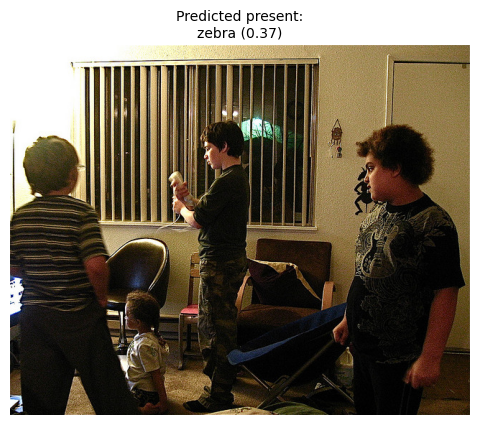

In [31]:
import matplotlib.pyplot as plt

def show_prediction(img_pil, present, max_lines=12):
    plt.figure()
    plt.imshow(img_pil)
    plt.axis("off")

    lines = [f"{name} ({p:.2f})" for _, name, p in present[:max_lines]]
    title = "Predicted present:\n" + ("\n".join(lines) if lines else "(none above threshold)")
    plt.title(title, fontsize=10)
    plt.show()

show_prediction(img_pil, present)


In [58]:
import random
from pathlib import Path
import matplotlib.pyplot as plt

def show_prediction_grid_with_top10_no_overlap(
    folder_path: str | Path,
    rows: int = 10,
    cols: int = 10,
    threshold: float = 0.3,
    topk: int = 10,
    seed: int | None = None,
    exts = (".jpg", ".jpeg", ".png"),
    figsize_per_cell: float = 2.6,
    text_fontsize: int = 7,
):
    folder = Path(folder_path)
    if seed is not None:
        random.seed(seed)

    # Collect images
    image_paths = []
    for ext in exts:
        image_paths.extend(folder.glob(f"*{ext}"))

    total = rows * cols
    if len(image_paths) < total:
        raise ValueError(f"Folder has only {len(image_paths)} images, need {total}")

    chosen = random.sample(image_paths, total)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(cols * figsize_per_cell, rows * figsize_per_cell * 1.35)
    )
    axes = axes.flatten()

    for ax, img_path in zip(axes, chosen):
        img_pil, top, present = predict_one(
            img_path, threshold=threshold, topk=topk
        )

        # Show image
        ax.imshow(img_pil)
        ax.axis("off")

        # ---- Build text block ----
        lines = []

        # Predicted present
        if present:
            present_lines = [f"{name} ({prob:.2f})" for _, name, prob in present[:4]]
            lines.append("Present: " + ", ".join(present_lines))
        else:
            lines.append("Present: none ≥ thr")

        # Top-k
        top_lines = [f"{name} ({prob:.2f})" for _, name, prob in top[:topk]]
        lines.append("Top-10: " + ", ".join(top_lines))

        text = "\n".join(lines)

        # ---- Place text BELOW image ----
        ax.text(
            0.5, -0.18, text,
            ha="center", va="top",
            transform=ax.transAxes,
            fontsize=text_fontsize,
            wrap=True
        )

    plt.subplots_adjust(hspace=0.55, wspace=0.25)
    plt.show()


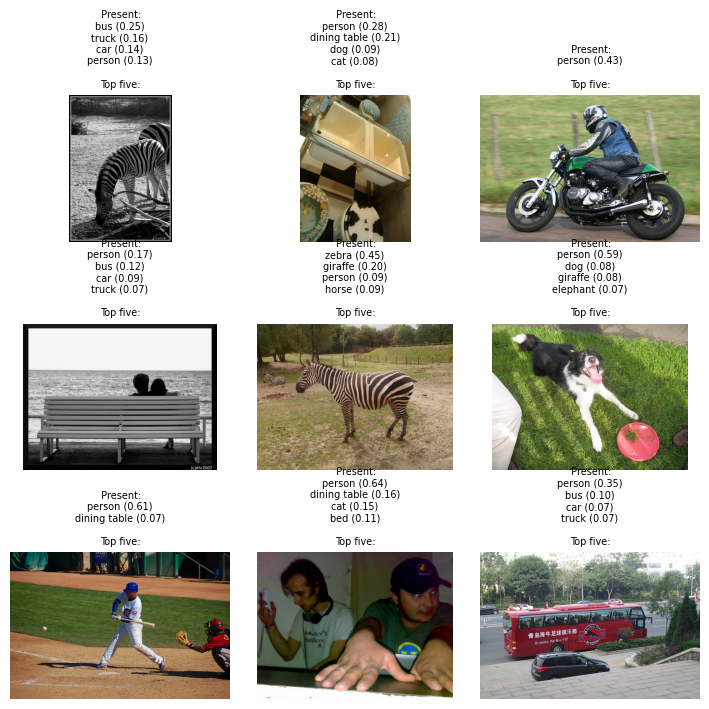

In [59]:
TEST_FOLDER = "/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v2/val_working2"  # EDIT THIS

show_prediction_grid_with_top10(
    TEST_FOLDER,
    rows=3,
    cols=3,
    threshold=0.05,
    topk=0,
    seed=5728
)